In [16]:
import pandas as pd
import matplotlib as plt

df = pd.read_csv("sales_data.csv")

In [17]:
df.head(10)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
5,1021,2023-02-11,Charlie,West,3761.15,32,Food,900.79,1106.51,New,0.21,Cash,Online,West-Charlie
6,1083,2023-04-11,Bob,West,618.31,29,Furniture,2408.81,2624.09,Returning,0.14,Cash,Online,West-Bob
7,1087,2023-01-06,Eve,South,7698.92,46,Furniture,3702.51,3964.65,New,0.12,Bank Transfer,Online,South-Eve
8,1075,2023-06-29,David,South,4223.39,30,Furniture,738.06,1095.45,New,0.05,Bank Transfer,Online,South-David
9,1075,2023-10-09,Charlie,West,8239.58,18,Clothing,2228.35,2682.34,New,0.13,Bank Transfer,Online,West-Charlie


In [18]:
df.shape
df.columns
df.dtypes

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 78.2+ KB


In [20]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[(df["Unit_Price"] < 0) | (df["Quantity_Sold"] == 0)]

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep


In [23]:
df_clean = df.copy()

# supprimer anomalies
df_clean = df_clean[(df_clean["Unit_Price"] >= 0) & (df_clean["Quantity_Sold"] > 0)]

# remplacer region manquante
df_clean["Region"] = df_clean["Region"].fillna("Inconnue")

# remplacer prix manquant
df_clean["Unit_Price"].fillna(df_clean["Unit_Price"].mean())

# supprimer doublons
df_clean = df_clean.drop_duplicates()

In [24]:
df_clean["Total"] = df_clean["Unit_Price"] * df_clean["Quantity_Sold"]

In [25]:
df_clean["Total"].sum()

np.float64(70329940.71)

In [26]:
df_clean["Total"].mean()

np.float64(70329.94071)

In [27]:
print("Classement des produits les plus vendus :")
df_clean.groupby("Product_ID")["Quantity_Sold"].sum().sort_values(ascending=False)

Classement des produits les plus vendus :


Product_ID
1090    590
1092    548
1062    506
1099    502
1058    452
       ... 
1083    125
1065    105
1011     75
1043     65
1031     64
Name: Quantity_Sold, Length: 100, dtype: int64

In [28]:
top_product = df_clean.groupby("Product_ID")["Quantity_Sold"].sum().sort_values(ascending=False).idxmax()
top_quantity = df_clean.groupby("Product_ID")["Quantity_Sold"].sum().sort_values(ascending=False).max()

print(f"Le produit le plus vendu est : {top_product}")
print(f"Quantité totale vendue : {top_quantity}")

Le produit le plus vendu est : 1090
Quantité totale vendue : 590


In [29]:
print("\nProduits les plus rentables :")
df_clean.groupby("Product_ID")["Total"].sum().sort_values(ascending=False)


Produits les plus rentables :


Product_ID
1090    1819857.91
1092    1738987.88
1099    1635859.89
1089    1445192.74
1054    1256881.40
           ...    
1065     296587.77
1041     288497.74
1011     244328.35
1031     223359.48
1043     191699.04
Name: Total, Length: 100, dtype: float64

In [30]:
best_product = df_clean.groupby("Product_ID")["Total"].sum().sort_values(ascending=False).idxmax()
best_revenue = df_clean.groupby("Product_ID")["Total"].sum().sort_values(ascending=False).max()

print(f"Produit le plus rentable : {best_product}")
print(f"Chiffre d'affaires : {best_revenue}")

Produit le plus rentable : 1090
Chiffre d'affaires : 1819857.91


In [31]:
df_clean.groupby("Customer_Type")["Total"].sum().sort_values(ascending=False)

Customer_Type
New          36529262.01
Returning    33800678.70
Name: Total, dtype: float64

In [32]:
print("\nChiffre d'affaires par région :")
df_clean.groupby("Region")["Total"].sum().sort_values(ascending=False)


Chiffre d'affaires par région :


Region
North    18208403.85
East     18077401.05
West     17761568.65
South    16282567.16
Name: Total, dtype: float64

In [33]:
best_region = df_clean.groupby("Region")["Total"].sum().sort_values(ascending=False).idxmax()
best_region_value = df_clean.groupby("Region")["Total"].sum().sort_values(ascending=False).max()

print(f"Région la plus rentable : {best_region}")
print(f"CA total : {best_region_value}")

Région la plus rentable : North
CA total : 18208403.85


In [34]:
df_clean["Product_Category"].value_counts()

Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64

In [35]:
df_clean.groupby("Product_Category")["Total"].mean()

Product_Category
Clothing       71965.425112
Electronics    71426.994187
Food           66999.494027
Furniture      70501.079077
Name: Total, dtype: float64

In [36]:
df_clean["Sale_Date"] = pd.to_datetime(
    df_clean["Sale_Date"],
    errors="coerce"
)

In [37]:
df_clean["Month"] = df_clean["Sale_Date"].dt.month

In [38]:
print("\nChiffre d'affaires par mois :")
df_clean.groupby("Month")["Total"].sum()


Chiffre d'affaires par mois :


Month
1     7488100.51
2     5627477.45
3     6008259.41
4     5468497.62
5     5800626.51
6     6142561.23
7     4751432.42
8     6716190.61
9     4557015.58
10    6560606.39
11    4958930.19
12    6250242.79
Name: Total, dtype: float64

In [39]:
best_month = df_clean.groupby("Month")["Total"].sum().idxmax()
best_month_value = df_clean.groupby("Month")["Total"].sum().max()

print(f"Meilleur mois : {best_month}")
print(f"CA : {best_month_value}")

Meilleur mois : 1
CA : 7488100.51


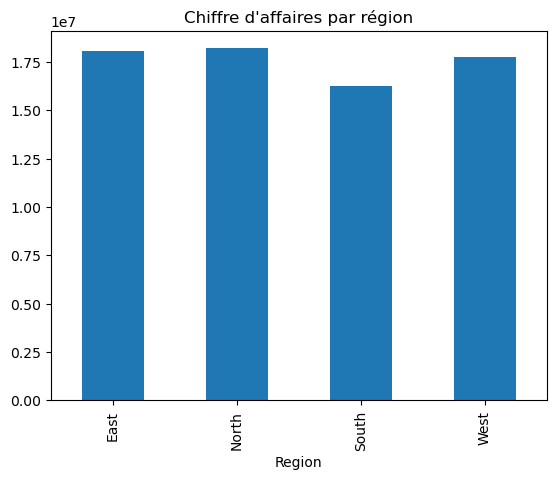

In [46]:
import matplotlib.pyplot as plt
df_clean.groupby("Region")["Total"].sum().plot(kind="bar")
plt.title("Chiffre d'affaires par région")
plt.show()

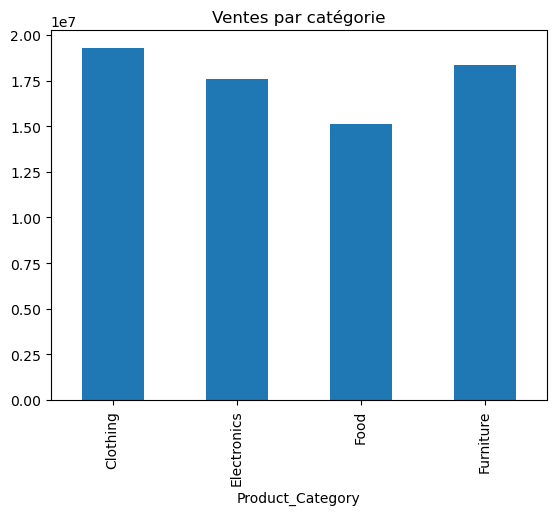

In [48]:
df_clean.groupby("Product_Category")["Total"].sum().plot(kind="bar")
plt.title("Ventes par catégorie")
plt.show()

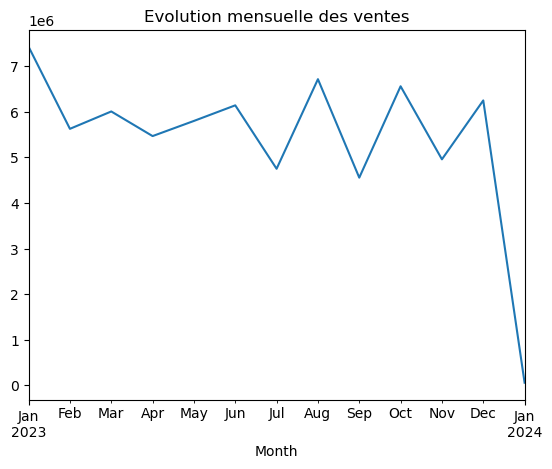

In [49]:
df_clean.groupby("Month")["Total"].sum().plot()
plt.title("Evolution mensuelle des ventes")
plt.show()